In [71]:
url = r"/workspaces/SML/SML /abalone.data"

In [72]:
column_names = [
    'Gender', 
    'Length', 
    'Diameter', 
    'Height', 
    'Whole_weight', 
    'Light_weight', 
    'Viscera_weight', 
    'Shell_weight', 
    'Rings'
]

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn import neighbors
from math import sqrt

In [74]:
import pandas as pd
df=pd.read_csv(url,names=column_names)
df.head()

,Gender,Length,Diameter,Height,Whole_weight,Light_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [75]:
df.isnull().sum()

Gender            0
Length            0
Diameter          0
Height            0
Whole_weight      0
Light_weight      0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

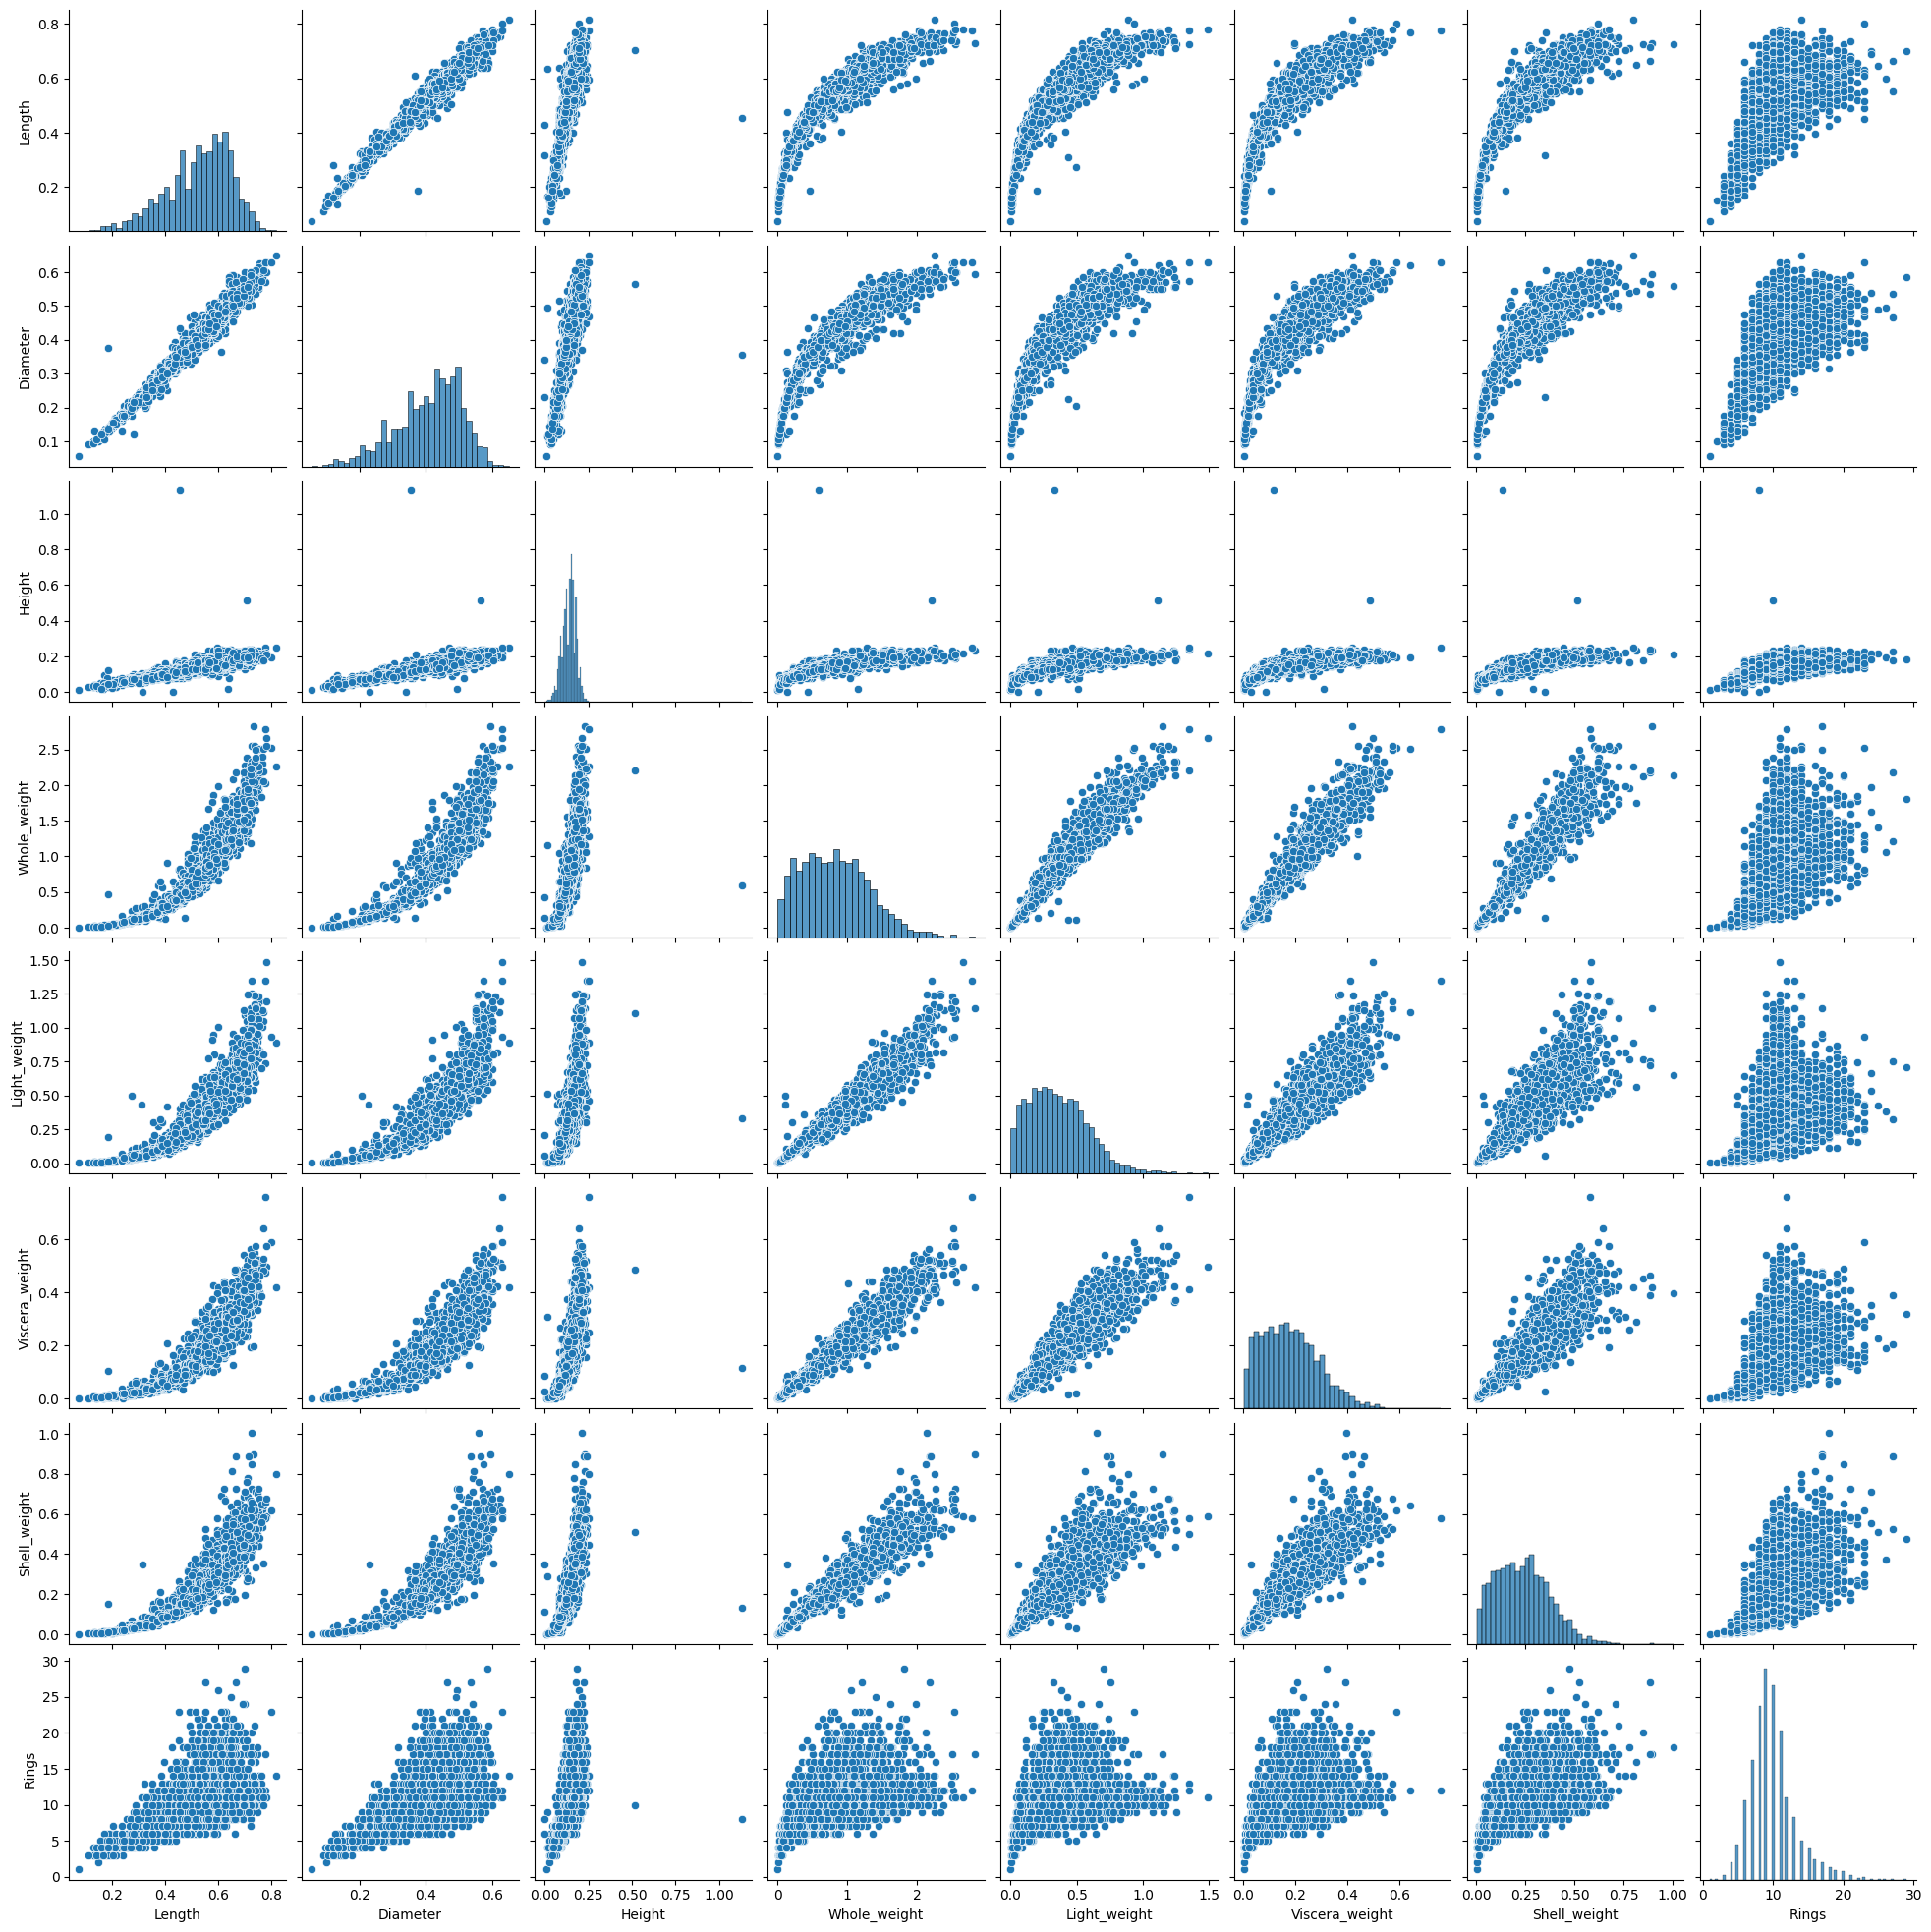

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(df)
plt.show

In [77]:
# This creates columns like Sex_F, Sex_I, Sex_M
df = pd.get_dummies(df)

In [78]:
# Impute numerical with mean
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].mean())

In [79]:
x = df.drop('Rings', axis=1)
y = df['Rings']

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)



In [81]:
# Scaling features
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_train = pd.DataFrame(x_train_scaled)
x_test_scaled = scaler.transform(x_test) # Corrected to .transform to avoid leakage
x_test = pd.DataFrame(x_test_scaled)

In [82]:
rmse_val = []
k_list = []
for K in range(50):
    K = K+1
    model = neighbors.KNeighborsRegressor(n_neighbors=K)

    model.fit(x_train,y_train)
    pred = model.predict(x_test)
    error = sqrt(mean_squared_error(y_test,pred))
    rmse_val.append(error)
    k_list.append(K)

    print("RMSE value for k =",K,"is",error)


RMSE value for k = 1 is 2.8191077349141223
RMSE value for k = 2 is 2.4690670031468787
RMSE value for k = 3 is 2.3589765815155803
RMSE value for k = 4 is 2.3051131535605154
RMSE value for k = 5 is 2.256685972603935
RMSE value for k = 6 is 2.2208245870702013
RMSE value for k = 7 is 2.2078729563188966
RMSE value for k = 8 is 2.1960317217577954


RMSE value for k = 9 is 2.20154074609651
RMSE value for k = 10 is 2.182202916636762
RMSE value for k = 11 is 2.1916523573832727
RMSE value for k = 12 is 2.1816437330578133
RMSE value for k = 13 is 2.1828929778795856
RMSE value for k = 14 is 2.185949337861657
RMSE value for k = 15 is 2.1849646518559527
RMSE value for k = 16 is 2.186807819401425
RMSE value for k = 17 is 2.188470859025812
RMSE value for k = 18 is 2.1878488557553477
RMSE value for k = 19 is 2.1928805482911167
RMSE value for k = 20 is 2.193102133895494
RMSE value for k = 21 is 2.1984629410486125
RMSE value for k = 22 is 2.1940341764768556
RMSE value for k = 23 is 2.1885951053581754
RMSE value for k = 24 is 2.182106937704367
RMSE value for k = 25 is 2.1864667119843446
RMSE value for k = 26 is 2.1847457976249105
RMSE value for k = 27 is 2.185360887039353
RMSE value for k = 28 is 2.1900762690044027
RMSE value for k = 29 is 2.1927999438565844
RMSE value for k = 30 is 2.1960363743744677
RMSE value for k = 31 is 2.192294733894878

In [83]:
best_rmse_score= min(rmse_val)
best_k = k_list[rmse_val.index(best_rmse_score)]
print("Optimum K value=",best_k,"with Score=",best_rmse_score)

Optimum K value= 12 with Score= 2.1816437330578133


<Axes: >

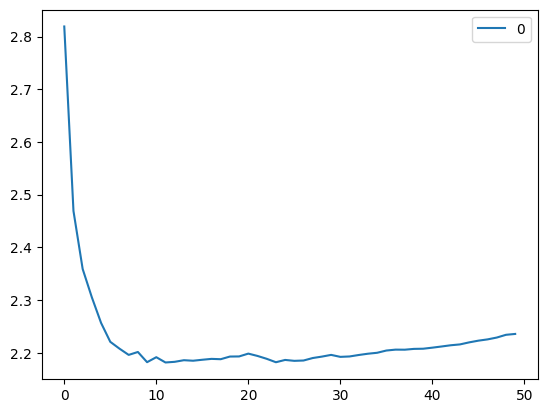

In [84]:
#ploting  the rmse values against k values
curve = pd.DataFrame(rmse_val) #elbow curve
curve.plot()